![](https://i.imgur.com/dbbaf88.png)

# AIC-502 - Assessment 3-4

## Update on Nov 18, 2023.
Now this notebook is for Assessment 3 and Assessment 4 as announced in the CMKL canvas (private link for CMKL students)
https://cmkl.instructure.com/courses/268/discussion_topics/1700

To help you guys get some ideas the criteria I used to grade all the assessment. They are the following :
 * **Your efforts , your creativities and thoughtful explanations about the asked question**. In particular, in an open question, where we need to show ideas, one cannot expect to get a good score by give a very crude and short answer.
 * **Well written and organized explanation.** Especially in the report of Assessment 3 & 4. Also the explanation parts on assessment 2 (you still have time to improve you’re answer). Actually you can try use ChatGPT to organize/improve your written essay. But make sure that it is (1) not too redundant as ChatGPT tends to say the same thing several times and (2) your main logic is still correct & valid as ChatGPT is not so good with logical reasoning
 * **Good code.** If the question involves coding, it is very important to show your coding skill. Therefore, show me the clean, neat and runnable code is the best way to get high score. Note, however, no copy & paste from your friends.
 * **Uniqueness of your answer / code.** It is very unlikely that two students will have exact same answers / codes by accident. So if I observe this phenomenon, it is unavoidable to me to reduce some scores . I 100% encourage all of you to discuss, and help friends but not copy/paste


## Description Version Nov 7, 2023. (Updated on Nov 18)


## Objectives
* Understand how (Double) Deep Q-Learning is coded from scratch (Pytorch)
* Understand how we apply (Double) Deep Q-Learning to a famous Mario game
* Experience and understand the process of training Deep Q-Learning in complex environment like Mario
* Be able to improve Mario agent code



## Your Tasks

**Task-1** Read and make sure to understand how Deep Q-Learning is coded and applied to Mario game. </br>
This is a very good example of Python and RL programming in practice. </br>
If you don't understand it well enough, you will not be able to do Task-3 below.

**Task-2 [Assessment 3]**

2.1) Train and try to play the trained Mario agent periodically as many episodes as you can e.g. upto 100,000 episodes. </br>
By periodically, I mean you try, save and play every 2000-3000 to see your trained agent. </br>
You can use Kaggle offline training as your training tool. Note that Kaggle offline can be executed at maximum 12 hours/run. </br>

When each training session is finished (finishing offline running), you will get the following in Notebook "Output"

* Training log of `Mean Reward, Mean Length, Mean Loss and Mean Q Value` (by default, located in Output/checkpoints/log where you can open it with notepad)

![](https://i.imgur.com/aWMAUsd.png)

* Video of example play
* Deep Q Network weights & other parameters (e.g. exploration rate) to be loaded in the next Kaggle notebook

**Please consult your 3 friends : Aut, Mhon' and Pokpong on how to load the previous-trained Deep Q-Network weight into the new version of Kaggle notebook**

2.2) Record/Collect these three outputs periodically to be submitted as assessment.
The submitted assessment should consist of two parts : written report in pdf and youtube-video public-shared link.

* Youtube single clip -- concat/connect all periodical saved videos together into one clip and upload into youtube. </br>
If possible, make a label (the number of trained episodes) for each video when concat them, </br>
so that when you combine into a single clip, it is easy to understand how the agent improve (or not) over time of training more and more. </br>

(use commonsense of explanation to make your audience understand what's going on)

Please also write your name somewhere in the youtube description. </br>

2.3) Pdf report. Make a report of your agent training progress. 

* Explain what have you observed during these long trained episodes.
* Look at the map in the top of each notebook, and see how far your agent can go each time
* Make (concat) plots of `Mean Reward, Mean Length, Mean Loss and Mean Q Value`
* Analyze your agents. Is him smart enough?? If not, why? what should be the cause? and how should you improve it? -- write all ideas

Don't worry if your agent is not so smart as RL is hard. The intention of this assessment is to let you experiment real-world RL by yourself. </br>
**Therefore the main point is about making a good experiment report with well-written and thoughtful analysis.**


**Task-3 [Assessment 4]** </br>
Improve/Modify a Mario agent in some useful way and also make recorded videos similar to task-2, so that we are be able to compare the two. </br>
This task is open-end. You are free to use any ideas, see from some research papers, etc. </br>

**Your modification doesn't always need to improve the performance ... Your good efforts, creativities, thoughful and well-explained can be enough to get good points**

Some suggestion that you can use (choose one of them or more if you can) -- this is just my random/brainstorming ideas --- it may work or not work

* Improve "reward" (see Lecture 5 on reward shaping) given to the agent. Current reward is written [here](https://github.com/Kautenja/gym-super-mario-bros/tree/master), which may not be good enough e.g. it doesn't take into account the mushroom eaten.
* Expand action space. Now the action contain only "right" and "jump-right" which you can see from mario map that you cannot go down the tunnel to get shortcut path
* Try import stable-baseline3 to this notebookand replace DDQ with other algorithms such as PPO (see [lab1](https://www.kaggle.com/code/ratthachat/intro-to-rl-refactor-from-rl-with-lux-1/notebook)).
* As can see from the Mario map, there are the underground shortcut that can be access via a tunnel, but it needs the action "down". Is it possible to add more actions ?
* Make sure agent have good memory in the replay, and implement "Priority" Experience Replay and see if it improves your agent or not
* Convert Pytorch code into Keras and get similar performance
* Or, the easiest things you can try is to optimize hyperparameters e.g. `exploration_rate_decay, gamma, etc.` or try different loss-function. (not required much Python's skill)
* You can also try port this notebook to run in your local PC so that you can run all episodes contiously for a few days ...

Make another youtube-clip and report comparable to Task-2,  so that we can compare. **Beside clip and report, you also need to submit the modified runnable Kaggle notebook**, or your own local notebook if you choose to train locally.
**Your modification doesn't always need to improve the performance ... Your creativity, good efforts, well-written and thoughtful analysis can be enough to get extra points**

**Show me what you've got .. **



**Please note that it may take some times to train the agent, so don't wait until almost the end of the semester to do this assessment!**
-----

In [1]:
# TODO: make a versioning txt file
TRAIN_EPISODES = 1500
SAVE_PATH = '/kaggle/working/mario_net_last.chkpt'

In [2]:
!pip install pyglet==1.4.11

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.1 MB/s eta 0:00:00


In [3]:
!sudo apt-get update
!sudo apt-get install -y python3-opengl
!apt install -q ffmpeg
!apt install -y xvfb
!pip3 install -q pyvirtualdisplay

Get:1 https://packages.cloud.google.com/apt cloud-sdk InRelease [6361 B]
Get:2 http://packages.cloud.google.com/apt gcsfuse-focal InRelease [1225 B]
Get:3 http://security.ubuntu.com/ubuntu focal-security InRelease [114 kB]
Get:4 https://packages.cloud.google.com/apt cloud-sdk/main amd64 Packages [624 kB]
Hit:5 http://archive.ubuntu.com/ubuntu focal InRelease
Get:6 http://archive.ubuntu.com/ubuntu focal-updates InRelease [114 kB]
Get:7 http://security.ubuntu.com/ubuntu focal-security/multiverse amd64 Packages [29.8 kB]
Get:8 http://security.ubuntu.com/ubuntu focal-security/main amd64 Packages [3547 kB]
Get:9 http://archive.ubuntu.com/ubuntu focal-backports InRelease [108 kB]
Get:10 http://security.ubuntu.com/ubuntu focal-security/restricted amd64 Packages [3490 kB]
Get:11 http://security.ubuntu.com/ubuntu focal-security/universe amd64 Packages [1195 kB]
Get:12 http://archive.ubuntu.com/ubuntu focal-updates/universe amd64 Packages [1492 kB]
Get:13 http://archive.ubuntu.com/ubuntu focal-u

In [4]:
# !pip3 install -U torch  # If in the future, Colab update its environment, we may try specifically torch version 2.1.0+cu121

!pip3 install torch==2.1.0+cpu --extra-index-url https://download.pytorch.org/whl/cpu/ -U

!pip install -q tensordict==0.2.1
!pip install -q torchrl==0.2.1
# !pip install -q torchsnapshot

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.9/184.9 MB 5.8 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.0.0+cpu
    Uninstalling torch-2.0.0+cpu:
      Successfully uninstalled torch-2.0.0+cpu
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.7.12 requires torch<2.1,>=1.7, but you have torch 2.1.0+cpu which is incompatible.
torchaudio 2.0.1+cpu requires torch==2.0.0, but you have torch 2.1.0+cpu which is incompatible.
torchdata 0.6.0 requires torch==2.0.0, but you have torch 2.1.0+cpu which is incompatible.
torchtext 0.15.1+cpu requires torch==2.0.0, but you have torch 2.1.0+cpu which is incompatible.
torchvision 0.15.1+cpu requires torch==2.0.0, but you have torch 2.1.0+cpu which is incompatible.


In [5]:
import os
# os.kill(os.getpid(), 9)

In [6]:
# For tips on running notebooks in Google Colab, see
# https://pytorch.org/tutorials/beginner/colab
%matplotlib inline

In [7]:
# Virtual display
from pyvirtualdisplay import Display

virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()


# Train a Mario-playing RL Agent

**Credit : Original Authors:** [Yuansong Feng](https://github.com/YuansongFeng)_, [Suraj Subramanian](https://github.com/suraj813)_, [Howard Wang](https://github.com/hw26)_, [Steven Guo](https://github.com/GuoYuzhang)_.

**Instruction, Exercises & Videos are added for AIC-502 students. Also Torch versioning is fixed so that Colab is now runable as of Oct 18, 2023**

This tutorial walks you through the fundamentals of Deep Reinforcement
Learning. At the end, you will implement an AI-powered Mario (using
[Double Deep Q-Networks](https://arxiv.org/pdf/1509.06461.pdf)_) that
can play the game by itself.

Although no prior knowledge of RL is necessary for this tutorial, you
can familiarize yourself with these RL
[concepts](https://spinningup.openai.com/en/latest/spinningup/rl_intro.html)_,
and have this handy
[cheatsheet](https://colab.research.google.com/drive/1eN33dPVtdPViiS1njTW_-r-IYCDTFU7N)_
as your companion. The full code is available
[here](https://github.com/yuansongFeng/MadMario/)_.

You can see details of Mario mode & reward function [here](https://github.com/Kautenja/gym-super-mario-bros/tree/master).

.. figure:: /_static/img/mario.gif
   :alt: mario


# TASK 4

I have decided to try and use Prioritized Experienced Replay to improve the Mario Agent. To start, I took a read at this paper Schaul, T., Quan, J., Antonoglou, I., Silver, D., *Prioritized Experience Replay*, Arxiv, Published as a conference paper at ICLR 2016, https://arxiv.org/pdf/1511.05952.pdf. 

Then, I took a look at some examples from Schroeder, K., *Prioritized Experience Replay with TF-Agents*, Medium, https://kenneth-schroeder-dev.medium.com/prioritized-experience-replay-with-tf-agents-3fa2498f411a 

and TheComputerScientist, *How To Speed Up Training With Prioritized Experience Replay*, Youtube, https://www.youtube.com/watch?v=MqZmwQoOXw4

To summarize, experience replay lets agents remember and reuse experiences gathered from the past to improve learning. In original code, it replays memory at the same level regardless of its importance *but* prioritized experience replay, as its name suggests, will prioritize the most important experiences and allow for rare experiences that could be useful later on. 'In general, experience replay can reduce the amount of experience required to learn, and replace it with more computation and more memory', (Schaul, T., et al.)

The downsides is that is can lead to a loss of diversity and introduce bias but can be improved with stochastic prioritization and importance sampling respectively. 

**Blind Cliffwalk**

-When there are n states, the chance that a random sequence of actions will lead to reward is 2^-n. <br>
-Most relevant transitions are hidden in failure cases

**TD-error**

We want to select transition that will most reduce the global loss in current state. We can use TD errror 'how far value is from its next-step bootstrap estimate, (Schaul, T., et al.). We can also use binary heap data structure when there is large memory size N. 

The downsides are that TD errors only update for transitions that are replayed so transitions that have low TD error on first run may not be replayed for long time. Moreover, it focuses on small subset of experience so may be prone to overfitting. 

The article introduces sampling method that implements both pure greedy prioritization and uniform random sampling.

**IS weights**
To reduce bias, they propose importance-sampling (IS) weights that compensates for non-uniform probabilities P(i) if beta = 1. 

Weights are also normalized by 1/maxiwi

In conclusion, prioritization makes high-error transitions seen many times, IS correction then reduces gradient magnitude

**Prioritized Experienced Replay Implementation**

In our replay buffer, we can assign priorities to each experience tuple representing the learning value of each tuple. E.g.

$exp_2$,$p_2$ <br>
$exp_3$,$p_3$ <br>
$exp_4$,$p_4$

1. define priority 

error = q(s,a) - q_target
p = |error| + offset

*the offset is used to make sure priority is not 0 if error is 0 because the experience might be useful later on*

2. define sampling probability

Pr(i) = $\frac{{p_i}^{a}}{Σ{p}^{a}}$

*the priority could have approximation errors (due to q-target) which could cause priority to be too high or too low, a is used to dampen priority. a = 1 results in full priority, a = 0 random sampling* <br>

3. for each layer in Q network, we update weights and biases

*because we are sampling non uniformly, this would create bias towards high priorities and overfitting

loss = our loss implementation

θ = θ - α $\frac{dloss}{dθ}$ w

4. define weighting factor to address bias 

${w_i}$ = $({\frac{1}{N}} * {\frac{1}{Pr(i)}})^b$

*since bias correction is more useful later on, we can introduce value b which increases overtime


In [8]:
%%bash
pip install -q gym-super-mario-bros==7.4.0

In [9]:
import torch
print(torch.__version__) # LOG: runnable with version 2.1.0+cu121

2.1.0+cpu


In [10]:

from torch import nn
from torchvision import transforms as T
from PIL import Image
import numpy as np
from pathlib import Path
from collections import deque
import random, datetime, os, copy
import collections

# Gym is an OpenAI toolkit for RL
import gym
from gym.spaces import Box
from gym.wrappers import FrameStack

# NES Emulator for OpenAI Gym
from nes_py.wrappers import JoypadSpace

# Super Mario environment for OpenAI Gym
import gym_super_mario_bros

from tensordict import TensorDict
from torchrl.data import TensorDictReplayBuffer, LazyMemmapStorage

from gym.wrappers.frame_stack import LazyFrames

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

## RL Definitions

**Environment** The world that an agent interacts with and learns from.

**Action** $a$ : How the Agent responds to the Environment. The
set of all possible Actions is called *action-space*.

**State** $s$ : The current characteristic of the Environment. The
set of all possible States the Environment can be in is called
*state-space*.

**Reward** $r$ : Reward is the key feedback from Environment to
Agent. It is what drives the Agent to learn and to change its future
action. An aggregation of rewards over multiple time steps is called
**Return**.

**Optimal Action-Value function** $Q^*(s,a)$ : Gives the expected
return if you start in state $s$, take an arbitrary action
$a$, and then for each future time step take the action that
maximizes returns. $Q$ can be said to stand for the “quality” of
the action in a state. We try to approximate this function.




## Environment

### Initialize Environment

In Mario, the environment consists of tubes, mushrooms and other
components.

When Mario makes an action, the environment responds with the changed
(next) state, reward and other info.




In [12]:
print(gym.__version__)

0.26.2


In [13]:
# Initialize Super Mario environment (in v0.26 change render mode to 'human' to see results on the screen)
if gym.__version__ < '0.26':
    env = gym_super_mario_bros.make("SuperMarioBros-1-1-v0", new_step_api=True)
    print(1)
else:
    env = gym_super_mario_bros.make("SuperMarioBros-1-1-v0", render_mode='rgb_array', apply_api_compatibility=True)
    print(2)

# Limit the action-space to
#   0. walk right
#   1. jump right
env = JoypadSpace(env, [["right"], ["right", "A"]])

env.reset()
next_state, reward, done, trunc, info = env.step(action=0)
print(f"{next_state.shape},\n {reward},\n {done},\n {info}")

/opt/conda/lib/python3.10/site-packages/gym/envs/registration.py:555: UserWarning: WARN: The environment SuperMarioBros-1-1-v0 is out of date. You should consider upgrading to version `v3`.
  logger.warn(
/opt/conda/lib/python3.10/site-packages/gym/envs/registration.py:627: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['render.modes', 'video.frames_per_second']
  logger.warn(


2
(240, 256, 3),
 0.0,
 False,
 {'coins': 0, 'flag_get': False, 'life': 2, 'score': 0, 'stage': 1, 'status': 'small', 'time': 400, 'world': 1, 'x_pos': 40, 'y_pos': 79}


### Preprocess Environment

Environment data is returned to the agent in ``next_state``. As you saw
above, each state is represented by a ``[3, 240, 256]`` size array.
Often that is more information than our agent needs; for instance,
Mario’s actions do not depend on the color of the pipes or the sky!

We use **Wrappers** to preprocess environment data before sending it to
the agent.

``GrayScaleObservation`` is a common wrapper to transform an RGB image
to grayscale; doing so reduces the size of the state representation
without losing useful information. Now the size of each state:
``[1, 240, 256]``

``ResizeObservation`` downsamples each observation into a square image.
New size: ``[1, 84, 84]``

``SkipFrame`` is a custom wrapper that inherits from ``gym.Wrapper`` and
implements the ``step()`` function. Because consecutive frames don’t
vary much, we can skip n-intermediate frames without losing much
information. The n-th frame aggregates rewards accumulated over each
skipped frame.

``FrameStack`` is a wrapper that allows us to squash consecutive frames
of the environment into a single observation point to feed to our
learning model. This way, we can identify if Mario was landing or
jumping based on the direction of his movement in the previous several
frames.




In [14]:
class SkipFrame(gym.Wrapper):
    def __init__(self, env, skip):
        """Return only every `skip`-th frame"""
        super().__init__(env)
        self._skip = skip

    def step(self, action):
        """Repeat action, and sum reward"""
        total_reward = 0.0
        for i in range(self._skip):
            # Accumulate reward and repeat the same action
            obs, reward, done, trunk, info = self.env.step(action)
            total_reward += reward
            if done:
                break
        return obs, total_reward, done, trunk, info


class GrayScaleObservation(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        obs_shape = self.observation_space.shape[:2]
        self.observation_space = Box(low=0, high=255, shape=obs_shape, dtype=np.uint8)

    def permute_orientation(self, observation):
        # permute [H, W, C] array to [C, H, W] tensor
        observation = np.transpose(observation, (2, 0, 1))
        observation = torch.tensor(observation.copy(), dtype=torch.float)
        return observation

    def observation(self, observation):
        observation = self.permute_orientation(observation)
        transform = T.Grayscale()
        observation = transform(observation)
        return observation


class ResizeObservation(gym.ObservationWrapper):
    def __init__(self, env, shape):
        super().__init__(env)
        if isinstance(shape, int):
            self.shape = (shape, shape)
        else:
            self.shape = tuple(shape)

        obs_shape = self.shape + self.observation_space.shape[2:]
        self.observation_space = Box(low=0, high=255, shape=obs_shape, dtype=np.uint8)

    def observation(self, observation):
        transforms = T.Compose(
            [T.Resize(self.shape), T.Normalize(0, 255)]
        )
        observation = transforms(observation).squeeze(0)
        return observation


# Apply Wrappers to environment
env = SkipFrame(env, skip=4)
env = GrayScaleObservation(env)
env = ResizeObservation(env, shape=84)
if gym.__version__ < '0.26':
    env = FrameStack(env, num_stack=4, new_step_api=True)
else:
    env = FrameStack(env, num_stack=4)

After applying the above wrappers to the environment, the final wrapped
state consists of 4 gray-scaled consecutive frames stacked together, as
shown above in the image on the left. Each time Mario makes an action,
the environment responds with a state of this structure. The structure
is represented by a 3-D array of size ``[4, 84, 84]``.

.. figure:: /_static/img/mario_env.png
   :alt: picture





(240, 256, 3)


/opt/conda/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:272: UserWarning: WARN: No render modes was declared in the environment (env.metadata['render_modes'] is None or not defined), you may have trouble when calling `.render()`.
  logger.warn(


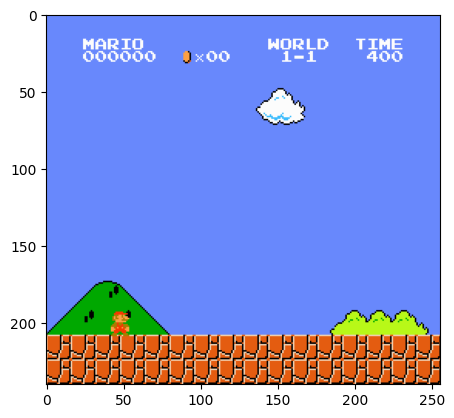

In [15]:
state = env.reset()

# if gym.__version__ > '0.26': render got no rgb_array arg
# img = env.render("rgb_array").copy() # IMPORTANT: render keep modifying the same object
img = env.render().copy() # IMPORTANT: render keep modifying the same object

print(img.shape)
plt.imshow(img)

In [16]:
def first_if_tuple(x):
    return x[0] if isinstance(x, tuple) else x

In [17]:
print(env.action_space)
print(env.action_space.n)

print(first_if_tuple(state).shape)
print(env.action_space.n)

Discrete(2)
2
(4, 84, 84)
2


(4, 84, 84),
 2.0,
 False,
 {'coins': 0, 'flag_get': False, 'life': 2, 'score': 0, 'stage': 1, 'status': 'small', 'time': 400, 'world': 1, 'x_pos': 44, 'y_pos': 122}
(240, 256, 3)


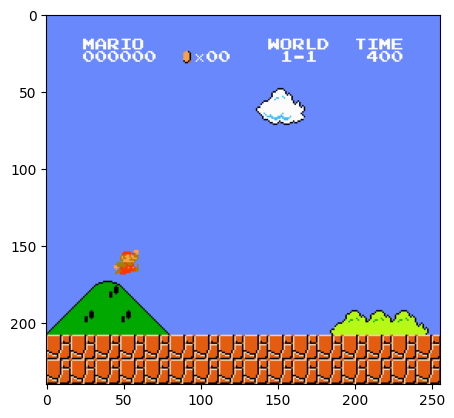

In [18]:
state = env.reset()
next_state, reward, done, trunc, info = env.step(action=1)
next_state, reward, done, trunc, info = env.step(action=1)
next_state, reward, done, trunc, info = env.step(action=1)
print(f"{first_if_tuple(next_state).shape},\n {reward},\n {done},\n {info}")
img2 = env.render()
print(img2.shape)
plt.imshow(img2)

In [19]:
class Mario:
    def __init__():
        pass
    
    def act(self, state):
        """Given a state, choose an epsilon-greedy action"""
        pass

    def cache(self, state, action, next_state, reward, done):
        """Add the experience to memory"""
        pass
    
    def get_probabilities(self, priority_scale):
        """Get probability of each priority"""
        pass
    
    def get_importance(self, probabilities):
        """Importance weight of sampling probability"""

    def recall(self, priority_scale):
        """Sample experiences from memory"""
        pass
    
    def update_priorities(self, indices, errors, offset):
        """Update priorities"""
        pass
    
    def learn(self, a):
        """Update online action value (Q) function with a batch of experiences"""
        pass


In the following sections, we will populate Mario’s parameters and
define his functions.




### Act

For any given state, an agent can choose to do the most optimal action
(**exploit**) or a random action (**explore**).

Mario randomly explores with a chance of ``self.exploration_rate``; when
he chooses to exploit, he relies on ``MarioNet`` (implemented in
``Learn`` section) to provide the most optimal action.




In [20]:
class Mario:
    def __init__(self, state_dim, action_dim, save_dir):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.save_dir = save_dir

        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        # Mario's DNN to predict the most optimal action - we implement this in the Learn section
        self.net = MarioNet(self.state_dim, self.action_dim).float()
        self.net = self.net.to(device=self.device)

        self.exploration_rate = 1
        self.exploration_rate_decay = 0.99999975
        self.exploration_rate_min = 0.1
        self.curr_step = 0

        self.save_every = 25000  # no. of steps of experiences between saving Mario Net

    def act(self, state):
        """
    Given a state, choose an epsilon-greedy action and update value of step.

    Inputs:
    state(``LazyFrame``): A single observation of the current state, dimension is (state_dim)
    Outputs:
    ``action_idx`` (``int``): An integer representing which action Mario will perform
    """
        # EXPLORE
        if np.random.rand() < self.exploration_rate:
            action_idx = np.random.randint(self.action_dim)

        # EXPLOIT
        else:
            state = state[0].__array__() if isinstance(state, tuple) else state.__array__()
            state = torch.tensor(state, device=self.device).unsqueeze(0)
            action_values = self.net(state, model="online")
            action_idx = torch.argmax(action_values, axis=1).item()

        # decrease exploration_rate
        self.exploration_rate *= self.exploration_rate_decay
        self.exploration_rate = max(self.exploration_rate_min, self.exploration_rate)

        # increment step
        self.curr_step += 1
        return action_idx

TASK 4 IMPLEMENTATION

In [21]:
class Mario(Mario):
    def __init__(self, state_dim, action_dim, save_dir):
        super().__init__(state_dim, action_dim, save_dir)
        
        #self.memory = deque(maxlen=100000)
        self.memory = TensorDictReplayBuffer(storage=LazyMemmapStorage(100000, device=torch.device("cpu")))
        self.batch_size = 32
        
        #for task 4: __init__ needs a new data structure to store priorities 
        #self.priorities = deque(maxlen=100000)
        self.priorities = np.zeros(100000)
        
        self.current_index = 0
        
        
    def cache(self, state, action, next_state, reward, done):
        """
        Store the experience to self.memory (replay buffer)

        Inputs:
        state (``LazyFrame``),
        next_state (``LazyFrame``),
        action (``int``),
        reward (``float``),
        done(``bool``))
        """
        
        state = first_if_tuple(state).__array__()
        next_state = first_if_tuple(next_state).__array__()

        state = torch.tensor(state)
        next_state = torch.tensor(next_state)
        action = torch.tensor([action])
        reward = torch.tensor([reward])
        done = torch.tensor([done])
        
        # Adding a transition to deque
        #self.memory.append({"state": state, "action": action, "next_state": next_state, "reward": reward, "done": done})

        self.memory.add(TensorDict({"state": state, "next_state": next_state, "action": action, "reward": reward, "done": done}, batch_size=[]))
        
        #first one being trained on has the max priorities so it has a higher chance of selected in the next batch
        max_priority = np.max(self.priorities) if self.priorities.size > 0 else 1
        self.priorities[self.current_index] = max_priority
        self.current_index = (self.current_index + 1) % len(self.priorities)
        #self.priorities.append(max(self.priorities, default=1))
        
        
    def get_probabilities(self, priority_scale):
        """
        This is the probability function P(i) = Pi^a / Ep^a
        """
        
        num_experiences = len(self.memory)
        
        #scaled_priorities = np.power(self.priorities[:num_experiences], priority_scale)
        #probabilities = scaled_priorities / np.sum(scaled_priorities)
        #probabilities = np.maximum(probabilities, 1e-10)
        
        #priorities_tensor = torch.tensor(list(self.priorities), dtype=torch.float32)
        #scaled_priorities = priorities_tensor ** priority_scale
        #probabilities = scaled_priorities / scaled_priorities.sum()
        
        #scaled_prob = np.array(self.priorities)**priority_scale 
        #sample_prob = scaled_prob / sum(scaled_prob)
        #probabilities = torch.tensor(sample_prob, dtype=torch.float32)
        #probabilities = torch.clamp(probabilities, min=1e-10)
        
        valid_priorities = np.maximum(self.priorities[:num_experiences], 1e-10)
        
        if priority_scale != 1:
            scaled_priorities = np.power(valid_priorities, priority_scale)
        else:
            scaled_priorities = valid_priorities

        total_priority = np.sum(scaled_priorities)
        probabilities = scaled_priorities / total_priority
        return probabilities
    
    
    def get_importance(self, probabilities):
        """
        Importance weight 1/N * 1/Pi
        """
        
        memory_length = len(self.memory) 
        importance = (1 / memory_length) / probabilities
        importance_normalized = importance / np.max(importance)
   
        #memory_length = len(self.memory)  
        #importance = (1 / torch.tensor(memory_length, dtype=torch.float32)) * (1 / probabilities)
        #importance_normalized = importance / importance.max()  
        
        #importance_normalized_tensor = torch.tensor(importance_normalized, dtype=torch.float32)
        #return importance_normalized_tensor
        return importance_normalized
        
    
    def recall(self, priority_scale=1.0):
        """
        Retrieve a batch of experiences from memory
        """
        sample_size = min(len(self.memory),self.batch_size)
        sample_prob = self.get_probabilities(priority_scale)
    
        #get position by putting in weights (our sampling probability) 
        #samples at the position 
        sample_indices = random.choices(range(len(self.memory)), k=sample_size, weights=sample_prob)    
        importance = self.get_importance(sample_prob[sample_indices])
        
        states, actions, next_states, rewards, dones = [], [], [], [], []
        for i in sample_indices:
            experience = self.memory[i]
            if isinstance(experience, TensorDict):
                state = experience['state'].cpu().numpy()
                action = experience['action'].cpu().numpy()[0]
                next_state = experience['next_state'].cpu().numpy()
                reward = experience['reward'].cpu().numpy()[0]
                done = experience['done'].cpu().numpy()[0]
                
                states.append(state)
                actions.append(action)
                next_states.append(next_state)
                rewards.append(reward)
                dones.append(done)
            
        states = torch.tensor(np.stack(states), dtype=torch.float32)
        actions = torch.tensor(np.array(actions), dtype=torch.int64)
        next_states = torch.tensor(np.stack(next_states), dtype=torch.float32)
        rewards = torch.tensor(np.array(rewards), dtype=torch.float32)
        dones = torch.tensor(np.array(dones), dtype=torch.float32)
        return states, actions, next_states, rewards, dones, importance, sample_indices
        
        #pass through the sampled probability
        #importance = self.get_importance(sample_prob[sample_indices])
        #return states, actions.squeeze(), next_states, rewards.squeeze(), dones.squeeze(), importance, sample_indices
        
        
        # batch = random.sample(self.memory, self.batch_size)
        # state, next_state, action, reward, done = map(torch.stack, zip(*batch))
        
        #batch = self.memory.sample(self.batch_size).to(self.device)
        #state, next_state, action, reward, done = (batch.get(key) for key in ("state", "next_state", "action", "reward", "done"))
        #return state, next_state, action.squeeze(), reward.squeeze(), done.squeeze()
    
    def update_priorities(self, indices, errors, offset=0.1):
        """
        Loop through each pair of indices and errors and set priority value of that index to absolute 
        """
        
        indices = np.asarray(indices)
        errors = np.asarray(errors)
        self.priorities[indices] = np.abs(errors) + offset

### Cache and Recall

These two functions serve as Mario’s “memory” process.

``cache()``: Each time Mario performs an action, he stores the
``experience`` to his memory. His experience includes the current
*state*, *action* performed, *reward* from the action, the *next state*,
and whether the game is *done*.

``recall()``: Mario randomly samples a batch of experiences from his
memory, and uses that to learn the game.

Learn more about ReplayBuffer
[HERE](https://colab.research.google.com/github/pytorch/rl/blob/gh-pages/_downloads/c64b1e484ba3e0219549719cc3c37479/rb_tutorial.ipynb)


### Learn

Mario uses the [DDQN algorithm](https://arxiv.org/pdf/1509.06461)_
under the hood. DDQN uses two ConvNets - $Q_{online}$ and
$Q_{target}$ - that independently approximate the optimal
action-value function.

In our implementation, we share feature generator ``features`` across
$Q_{online}$ and $Q_{target}$, but maintain separate FC
classifiers for each. $\theta_{target}$ (the parameters of
$Q_{target}$) is frozen to prevent updating by backprop. Instead,
it is periodically synced with $\theta_{online}$ (more on this
later).

#### Neural Network



In [22]:
class MarioNet(nn.Module):
    """mini CNN structure
  input -> (conv2d + relu) x 3 -> flatten -> (dense + relu) x 2 -> output
  """

    def __init__(self, input_dim, output_dim):
        super().__init__()
        c, h, w = input_dim

        if h != 84:
            raise ValueError(f"Expecting input height: 84, got: {h}")
        if w != 84:
            raise ValueError(f"Expecting input width: 84, got: {w}")

        self.online = nn.Sequential(
            nn.Conv2d(in_channels=c, out_channels=32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim),
        )

        self.target = copy.deepcopy(self.online)

        # Q_target parameters are frozen.
        for p in self.target.parameters():
            p.requires_grad = False

    def forward(self, input, model):
        if model == "online":
            return self.online(input)
        elif model == "target":
            return self.target(input)

#### TD Estimate & TD Target

Two values are involved in learning:

**TD Estimate** - the predicted optimal $Q^*$ for a given state
$s$

\begin{align}{TD}_e = Q_{online}^*(s,a)\end{align}

**TD Target** - aggregation of current reward and the estimated
$Q^*$ in the next state $s'$

\begin{align}a' = argmax_{a} Q_{online}(s', a)\end{align}

\begin{align}{TD}_t = r + \gamma Q_{target}^*(s',a')\end{align}

Because we don’t know what next action $a'$ will be, we use the
action $a'$ maximizes $Q_{online}$ in the next state
$s'$.

Notice we use the
[@torch.no_grad()](https://pytorch.org/docs/stable/generated/torch.no_grad.html#no-grad)_
decorator on ``td_target()`` to disable gradient calculations here
(because we don’t need to backpropagate on $\theta_{target}$).




In [23]:
class Mario(Mario):
    def __init__(self, state_dim, action_dim, save_dir):
        super().__init__(state_dim, action_dim, save_dir)
        self.gamma = 0.9

    def td_estimate(self, state, action):
        current_Q = self.net(state, model="online")[
            np.arange(0, self.batch_size), action
        ]  # Q_online(s,a)
        return current_Q

    @torch.no_grad()
    def td_target(self, reward, next_state, done):
        next_state_Q = self.net(next_state, model="online")
        best_action = torch.argmax(next_state_Q, axis=1)
        next_Q = self.net(next_state, model="target")[
            np.arange(0, self.batch_size), best_action
        ]
        return (reward + (1 - done.float()) * self.gamma * next_Q).float()

#### Updating the model

As Mario samples inputs from his replay buffer, we compute $TD_t$
and $TD_e$ and backpropagate this loss down $Q_{online}$ to
update its parameters $\theta_{online}$ ($\alpha$ is the
learning rate ``lr`` passed to the ``optimizer``)

\begin{align}\theta_{online} \leftarrow \theta_{online} + \alpha \nabla(TD_e - TD_t)\end{align}

$\theta_{target}$ does not update through backpropagation.
Instead, we periodically copy $\theta_{online}$ to
$\theta_{target}$

\begin{align}\theta_{target} \leftarrow \theta_{online}\end{align}





In [24]:
class Mario(Mario):
    def __init__(self, state_dim, action_dim, save_dir):
        super().__init__(state_dim, action_dim, save_dir)
        self.optimizer = torch.optim.Adam(self.net.parameters(), lr=0.00025)
        self.loss_fn = torch.nn.SmoothL1Loss()

    #caculates loss using Huber loss 
    def update_Q_online(self, td_estimate, td_target, importance):
        
        if isinstance(importance, np.ndarray):
            importance = torch.tensor(importance, dtype=torch.float32, device=td_estimate.device)
        
        loss = self.loss_fn(td_estimate, td_target)
        loss = (loss * importance).mean()
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        individual_errors = torch.abs(td_estimate - td_target).detach()
        return individual_errors

    def sync_Q_target(self):
        self.net.target.load_state_dict(self.net.online.state_dict())

#### Save checkpoint




In [25]:
class Mario(Mario):
    def save(self, save_path=None):
        save_path = (f"/kaggle/working/mario_net_{int(self.curr_step // self.save_every)}.pth")
        
        torch.save(
            dict(model=self.net.state_dict(),
                 optimizer_state_dict=self.optimizer.state_dict(),
                 exploration_rate=self.exploration_rate,
                 memory=self.memory,
                 #priority = self.priorities
                ),
            save_path,
        )
        print(f"MarioNet saved to {save_path} at step {self.curr_step}")

    def load(self, load_path):
        ckp = torch.load(load_path, map_location=('cuda' if self.use_cuda else 'cpu'))
        exploration_rate = ckp.get('exploration_rate')
        state_dict = ckp.get('model')

        print(f"Loading model at {load_path} with exploration rate {exploration_rate}")
        self.net.load_state_dict(state_dict)
        self.exploration_rate = exploration_rate
        self.optimizer.load_state_dict(ckp.get('optimizer_state_dict'))
#         self.memory = ckp.get('memory')

#### Putting it all together




In [26]:
class Mario(Mario):
    def __init__(self, state_dim, action_dim, save_dir, load_path=None):
        super().__init__(state_dim, action_dim, save_dir)
        self.burnin = 1e4  # min. experiences before training
        self.learn_every = 3  # no. of experiences between updates to Q_online
        self.sync_every = 1e4  # no. of experiences between Q_target & Q_online sync
       
        if load_path:
            self.load(load_path)
    def learn(self, a):
        if self.curr_step % self.sync_every == 0:
            self.sync_Q_target()

        if self.curr_step % self.save_every == 0:
            self.save()

        if self.curr_step < self.burnin:
            return None, None

        if self.curr_step % self.learn_every != 0:
            return None, None
        
        # Sample from memory and importance weight
        state, action, next_state, reward, done, importance, indices = self.recall(priority_scale=a)

        #Get TD Estimate
        td_est = self.td_estimate(state, action)

        # Get TD Target
        td_tgt = self.td_target(reward, next_state, done)

        # Backpropagate loss through Q_online
        errors = self.update_Q_online(td_est, td_tgt, importance**(1-self.exploration_rate))
                                    
        self.update_priorities(indices, errors)

        return (td_est.mean().item(), errors)

### Logging




In [27]:
import numpy as np
import time, datetime
import matplotlib.pyplot as plt


class MetricLogger:
    def __init__(self, save_dir):
        self.save_log = save_dir / "log"
        with open(self.save_log, "w") as f:
            f.write(
                f"{'Episode':>8}{'Step':>8}{'Epsilon':>10}{'MeanReward':>15}"
                f"{'MeanLength':>15}{'MeanLoss':>15}{'MeanQValue':>15}"
                f"{'TimeDelta':>15}{'Time':>20}\n"
            )
        self.ep_rewards_plot = save_dir / "reward_plot.jpg"
        self.ep_lengths_plot = save_dir / "length_plot.jpg"
        self.ep_avg_losses_plot = save_dir / "loss_plot.jpg"
        self.ep_avg_qs_plot = save_dir / "q_plot.jpg"

        # History metrics
        self.ep_rewards = []
        self.ep_lengths = []
        self.ep_avg_losses = []
        self.ep_avg_qs = []

        # Moving averages, added for every call to record()
        self.moving_avg_ep_rewards = []
        self.moving_avg_ep_lengths = []
        self.moving_avg_ep_avg_losses = []
        self.moving_avg_ep_avg_qs = []

        # Current episode metric
        self.init_episode()

        # Timing
        self.record_time = time.time()

    def log_step(self, reward, loss, q):
        self.curr_ep_reward += reward
        self.curr_ep_length += 1
        total_batch_loss = 0
        
        if loss is not None and loss.any():
            for loss_value in loss:
                total_batch_loss += loss_value.item()
            if total_batch_loss:
                self.curr_ep_loss += total_batch_loss
                self.curr_ep_q += q
                self.curr_ep_loss_length += 1
                

    def log_episode(self):
        "Mark end of episode"
        self.ep_rewards.append(self.curr_ep_reward)
        self.ep_lengths.append(self.curr_ep_length)
        if self.curr_ep_loss_length == 0:
            ep_avg_loss = 0
            ep_avg_q = 0
        else:
            ep_avg_loss = np.round(self.curr_ep_loss / self.curr_ep_loss_length, 5)
            ep_avg_q = np.round(self.curr_ep_q / self.curr_ep_loss_length, 5)
        self.ep_avg_losses.append(ep_avg_loss)
        self.ep_avg_qs.append(ep_avg_q)

        self.init_episode()

    def init_episode(self):
        self.curr_ep_reward = 0.0
        self.curr_ep_length = 0
        self.curr_ep_loss = 0.0
        self.curr_ep_q = 0.0
        self.curr_ep_loss_length = 0

    def record(self, episode, epsilon, step):
        mean_ep_reward = np.round(np.mean(self.ep_rewards[-100:]), 3)
        mean_ep_length = np.round(np.mean(self.ep_lengths[-100:]), 3)
        mean_ep_loss = np.round(np.mean(self.ep_avg_losses[-100:]), 3)
        mean_ep_q = np.round(np.mean(self.ep_avg_qs[-100:]), 3)
        self.moving_avg_ep_rewards.append(mean_ep_reward)
        self.moving_avg_ep_lengths.append(mean_ep_length)
        self.moving_avg_ep_avg_losses.append(mean_ep_loss)
        self.moving_avg_ep_avg_qs.append(mean_ep_q)

        last_record_time = self.record_time
        self.record_time = time.time()
        time_since_last_record = np.round(self.record_time - last_record_time, 3)

        print(
            f"Episode {episode} - "
            f"Step {step} - "
            f"Epsilon {epsilon} - "
            f"Mean Reward {mean_ep_reward} - "
            f"Mean Length {mean_ep_length} - "
            f"Mean Loss {mean_ep_loss} - "
            f"Mean Q Value {mean_ep_q} - "
            f"Time Delta {time_since_last_record} - "
            f"Time {datetime.datetime.now().strftime('%Y-%m-%dT%H:%M:%S')}"
        )

        with open(self.save_log, "a") as f:
            f.write(
                f"{episode:8d}{step:8d}{epsilon:10.3f}"
                f"{mean_ep_reward:15.3f}{mean_ep_length:15.3f}{mean_ep_loss:15.3f}{mean_ep_q:15.3f}"
                f"{time_since_last_record:15.3f}"
                f"{datetime.datetime.now().strftime('%Y-%m-%dT%H:%M:%S'):>20}\n"
            )

        for metric in ["ep_lengths", "ep_avg_losses", "ep_avg_qs", "ep_rewards"]:
            plt.clf()
            plt.plot(getattr(self, f"moving_avg_{metric}"), label=f"moving_avg_{metric}")
            plt.legend()
            plt.savefig(getattr(self, f"{metric}_plot"))

In [28]:


save_dir = Path("checkpoints") #/ datetime.datetime.now().strftime("%Y-%m-%dT%H-%M-%S")
if not os.path.exists(save_dir):
  save_dir.mkdir(parents=True)
print(f'All weights will saved at {save_dir}')



All weights will saved at checkpoints


In [29]:
# Initialize mario, this will re-init the weight
mario = Mario(state_dim=(4, 84, 84), action_dim=env.action_space.n, save_dir=save_dir)

In [30]:
use_cuda = torch.cuda.is_available()
print(f"Using CUDA: {use_cuda}")
print()

Using CUDA: False



In [31]:
## Ask your friends : Aut, Mon' or Pokpong, how to fix this cell so that the notebook can load the previously trained weight

try:    
    ckp = torch.load('/kaggle/input/mario-rl/mario_net_last.chkpt', map_location=('cuda' if use_cuda else 'cpu'))
    print(ckp.get('exploration_rate'))

    print(1)
    mario.exploration_rate = ckp.get('exploration_rate')
    mario.net.load_state_dict(ckp.get('model'))
    print(2)
    mario.optimizer.load_state_dict(ckp.get('optimizer_state_dict'))
#     mario.memory = ckp.get('memory')
except Exception as e:
    print(e)

[Errno 2] No such file or directory: '/kaggle/input/mario-rl/mario_net_last.chkpt'


## TRAINING Step

In this example we run the training loop for 100 episodes (took around <10 mins on Colab T4 GPU), but for Mario to truly learn the ways of
his world, we suggest running the loop for at least few ten thousand episodes!




In [32]:
import warnings
warnings.filterwarnings('ignore')

In [33]:


logger = MetricLogger(save_dir)



Episode 0 - Step 397 - Epsilon 0.999900754912699 - Mean Reward 764.0 - Mean Length 397.0 - Mean Loss 0.0 - Mean Q Value 0.0 - Time Delta 6.41 - Time 2024-04-12T08:47:11
Episode 20 - Step 6454 - Epsilon 0.9983878007897272 - Mean Reward 742.571 - Mean Length 307.333 - Mean Loss 0.0 - Mean Q Value 0.0 - Time Delta 96.964 - Time 2024-04-12T08:48:48
Episode 40 - Step 11897 - Epsilon 0.9970301683285793 - Mean Reward 833.244 - Mean Length 290.171 - Mean Loss 13.102 - Mean Q Value 0.559 - Time Delta 135.631 - Time 2024-04-12T08:51:04
Episode 60 - Step 14772 - Epsilon 0.9963138102774617 - Mean Reward 741.279 - Mean Length 242.164 - Mean Loss 22.037 - Mean Q Value 1.445 - Time Delta 126.515 - Time 2024-04-12T08:53:10
Episode 80 - Step 19197 - Epsilon 0.9952122474012991 - Mean Reward 737.667 - Mean Length 237.0 - Mean Loss 26.271 - Mean Q Value 1.898 - Time Delta 201.801 - Time 2024-04-12T08:56:32
Episode 100 - Step 24898 - Epsilon 0.9937948312944037 - Mean Reward 737.31 - Mean Length 245.01 - Me

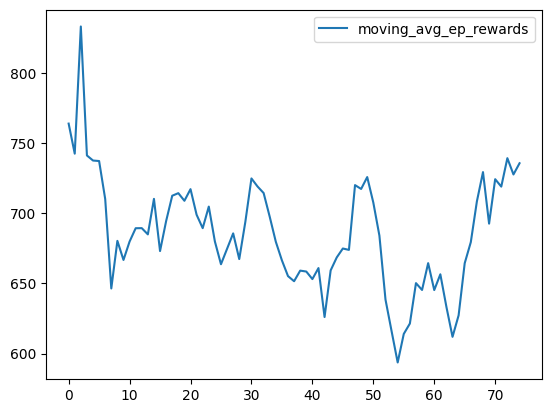

In [34]:
%%time
episodes = TRAIN_EPISODES # 7-8 mins per 100 episodes on T4 without fp16
for e in range(episodes):

    state = env.reset()

    # Play the game!
    while True:

        # Run agent on the state
        action = mario.act(state)

        # Agent performs action
        next_state, reward, done, trunc, info = env.step(action)
        
        mario.cache(state, action, next_state, reward, done)

        # Learn
        q, loss = mario.learn(a=(e%2==0)*0.7)

        # Logging
        logger.log_step(reward, loss, q)

        # Update state
        state = next_state

        # Check if end of game
        if done or info["flag_get"]:
            break

    logger.log_episode()

    if e % 20 == 0:
        logger.record(episode=e, epsilon=mario.exploration_rate, step=mario.curr_step)

## Display and Save Video

In [35]:
from ipywidgets import Video
VIDEO_NAME = "replay.webm" # you SHOULD change the name by adding #episodes that already trained

In [36]:
def animate(imgs, video_name=None, _return=True):
    # using cv2 to generate videos
    import cv2
    import os
    import string
    import random
    video_name = video_name if video_name is not None else ''.join(random.choice(string.ascii_letters) for i in range(18))+'.webm'
    height, width, layers = imgs[0].shape
    video = cv2.VideoWriter(video_name, cv2.VideoWriter_fourcc(*'VP80'), 20, (width,height))
    for img in imgs:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        video.write(img)
    video.release()
    if _return:
        from IPython.display import Video
        return Video(video_name)



In [37]:
import time

state = env.reset()
# time.sleep(0.03)
imgs = [env.render()]
# time.sleep(0.03)

i=0
while True:

    action = mario.act(state)
    next_state, reward, done, trunc, info = env.step(action)
    mario.cache(state, action, next_state, reward, done)

    state = next_state

    time.sleep(0.03)
    img = env.render().copy()
    # time.sleep(0.03)
    # assert np.any(img != imgs[-1])
    imgs += [img]

    i+=1
    if i%100==0:
        print(i)

    if done or info['flag_get']:
        break

100


In [38]:
print(len(imgs))
vid = animate(imgs, video_name=VIDEO_NAME, _return=True)


162


OpenCV: FFMPEG: tag 0x30385056/'VP80' is not supported with codec id 139 and format 'webm / WebM'


In [39]:
Video.from_file(VIDEO_NAME) # right-click on the bottom-right panel to download the video

Video(value=b'\x1aE\xdf\xa3\x9fB\x86\x81\x01B\xf7\x81\x01B\xf2\x81\x04B\xf3\x81\x08B\x82\x84webmB\x87\x81\x02B…

In [40]:
mario.save(SAVE_PATH)

MarioNet saved to /kaggle/working/mario_net_12.pth at step 324242


In [41]:
!pwd
!ls -sh


/kaggle/working
total 310M
336K __notebook__.ipynb   26M mario_net_12.pth	 26M mario_net_6.pth
4.0K checkpoints	  26M mario_net_2.pth	 26M mario_net_7.pth
 26M mario_net_1.pth	  26M mario_net_3.pth	 26M mario_net_8.pth
 26M mario_net_10.pth	  26M mario_net_4.pth	 26M mario_net_9.pth
 26M mario_net_11.pth	  26M mario_net_5.pth	400K replay.webm
